<a href="https://colab.research.google.com/github/Munazza-Farees/edunet-virtual-internship/blob/main/Steganography_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install all dependencies
!pip install pycryptodome opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 19.5 MB/s eta 0:00:00


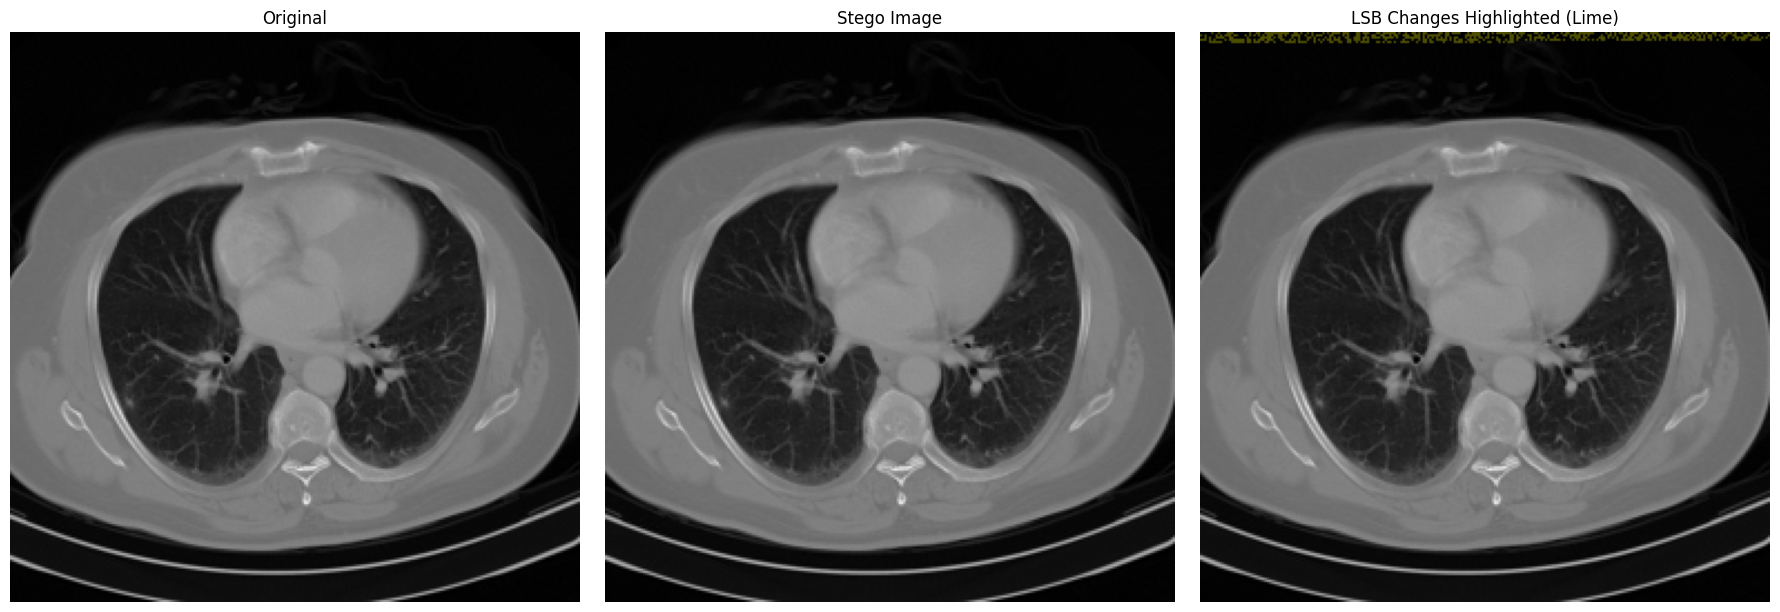

🔐 Original JSON Message:
{"patient_id": "M98646", "diagnosis": "Benign lesion", "timestamp": "2025-06-23 18:37"}

🔒 Encrypted (hex): 77572f813eeb8a9bbc5fa73f16e0663b9dff01fec3f46e5c7733eb2e9240a10b66c7086c98723998...

📈 SSIM: 1.0000

✅ Decrypted Message:
{"patient_id": "M98646", "diagnosis": "Benign lesion", "timestamp": "2025-06-23 18:37"}


In [10]:
# Import Libraries
import cv2, numpy as np, matplotlib.pyplot as plt, json, hmac, hashlib
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
from Crypto.Protocol.KDF import PBKDF2
from Crypto.Util.Padding import pad, unpad
from skimage.metrics import structural_similarity as ssim
from datetime import datetime

# Configuration
password = b"doctor_secure_access"
salt = b"medical_salt_2024"
patient_data = {
    "patient_id": "M98646",
    "diagnosis": "Benign lesion",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M")
}

image_path = "/content/drive/MyDrive/CT_Medical_Images_Dataset/ID_0004_AGE_0056_CONTRAST_1_CT.png"

# Helper Functions
def derive_key(password, salt, length=32):
    return PBKDF2(password, salt, dkLen=length, count=100000)

def encrypt_with_mac(msg_json, key):
    cipher = AES.new(key, AES.MODE_CBC)
    padded = pad(msg_json.encode(), AES.block_size)
    ct = cipher.encrypt(padded)
    mac = hmac.new(key, ct, hashlib.sha256).digest()
    full = cipher.iv + mac + ct
    length_bits = [int(b) for b in format(len(full) * 8, '016b')]
    payload_bits = [int(b) for byte in full for b in format(byte, '08b')]
    return np.array(length_bits + payload_bits, dtype=np.uint8), full.hex()

def decrypt_with_mac(full_bytes, key):
    iv, mac, ct = full_bytes[:16], full_bytes[16:48], full_bytes[48:]
    if hmac.new(key, ct, hashlib.sha256).digest() != mac:
        raise ValueError("MAC mismatch!")
    cipher = AES.new(key, AES.MODE_CBC, iv)
    return unpad(cipher.decrypt(ct), AES.block_size).decode()

def embed_lsb(img, bits):
    b, g, r = cv2.split(img)
    flat = b.flatten()
    if len(bits) > len(flat): raise ValueError("Message too large.")
    flat[:len(bits)] = (flat[:len(bits)] & 0xFE) | bits
    return cv2.merge([flat.reshape(b.shape), g, r])

def extract_lsb(img):
    b, _, _ = cv2.split(img)
    flat = b.flatten()
    detected_len = int("".join(str(flat[i] & 1) for i in range(16)), 2)
    payload = [flat[i] & 1 for i in range(16, 16 + detected_len)]
    return payload

def bits_to_bytes(bits):
    return bytes([int("".join(map(str, bits[i:i+8])), 2) for i in range(0, len(bits), 8)])

# Load the Image
image = cv2.imread(image_path)
if image is None:
    image = np.ones((256, 256, 3), dtype=np.uint8) * 200
    cv2.putText(image, 'CT', (100, 150), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 3)
image = cv2.resize(image, (256, 256))

# Encrypt the Message
message_json = json.dumps(patient_data)
key = derive_key(password, salt)
bits, encrypted_hex = encrypt_with_mac(message_json, key)

# Embed the image with message
stego = embed_lsb(image, bits)
cv2.imwrite("stego_secure.png", stego)

# Extract the message
extracted_bits = extract_lsb(stego)
extracted_bytes = bits_to_bytes(extracted_bits)

# Decrypt the message
try:
    decrypted = decrypt_with_mac(extracted_bytes, key)
except Exception as e:
    decrypted = f"❌ Error: {e}"

# SSIM Score
gray_orig = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_stego = cv2.cvtColor(stego, cv2.COLOR_BGR2GRAY)
score = ssim(gray_orig, gray_stego)

# Difference Map
diff = cv2.absdiff(image, stego)
diff_mask = np.any(diff != 0, axis=2).astype(np.uint8) * 255

overlay = image.copy()
highlight_color = (0, 255, 255)  # Lime/Yellow (BGR)
overlay[np.where(diff_mask == 255)] = highlight_color
highlighted = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

# Display pictures
# Original picture
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")


# Stego picture
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(stego, cv2.COLOR_BGR2RGB))
plt.title("Stego Image")
plt.axis("off")


# Differentiated picture
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB))
plt.title("LSB Changes Highlighted (Lime)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Outputs
print(f"🔐 Original JSON Message:\n{message_json}")
print(f"\n🔒 Encrypted (hex): {encrypted_hex[:80]}...")  # truncate
print(f"\n📈 SSIM: {score:.4f}")
print(f"\n✅ Decrypted Message:\n{decrypted}")